In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind

df = pd.read_csv('../../../data/processed/telco_customer_churn_clean.csv')

# วิเคราะห์ Internet Service ผลต่อ Churn 

## 1) ประเภท Internet Service ต่อ Churn

In [2]:
pd.crosstab(df["InternetService"], df["Churn"], normalize="index")

Churn,No,Yes
InternetService,,
DSL,0.810409,0.189591
Fiber optic,0.581072,0.418928
No,0.925950,0.074050


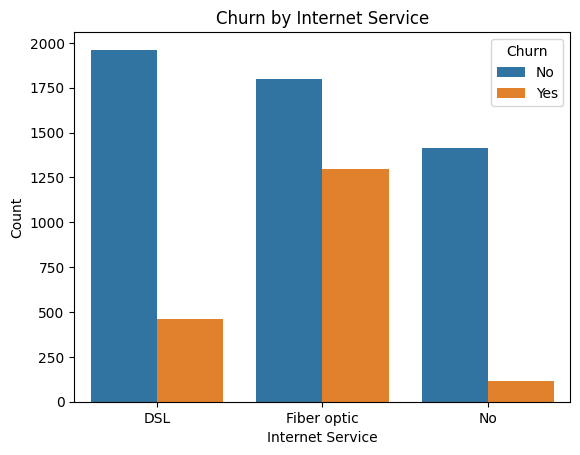

In [3]:
sns.countplot(data=df, x="InternetService", hue="Churn")
plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Count")
plt.legend(title="Churn", loc="upper right")
plt.show()

Fiber optic churn สูงเพราะอะไร?

H1: Fiber optic ทำให้ MonthlyCharges สูง
 
H2: MonthlyCharges สูง churn สูงตาม

<Axes: xlabel='InternetService', ylabel='MonthlyCharges'>

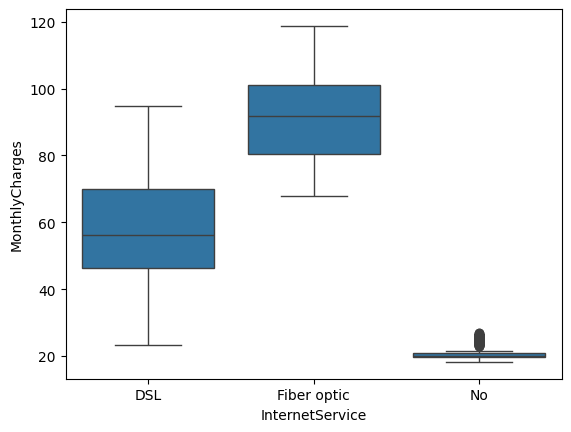

In [4]:
sns.boxplot(x="InternetService", y="MonthlyCharges", data=df)

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

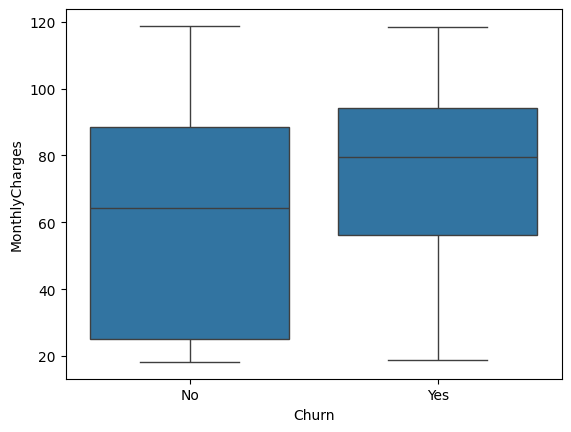

In [5]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)

In [6]:
pd.crosstab(
    [df["InternetService"], df["ChargeGroup"]],
    df["Churn"],
    normalize="index"
)

Churn                                  No       Yes
InternetService ChargeGroup                        
DSL             (18.249, 35.5]   0.639831  0.360169
                (35.5, 70.35]    0.788785  0.211215
                (70.35, 89.85]   0.935849  0.064151
                (89.85, 118.75]  0.980000  0.020000
Fiber optic     (35.5, 70.35]    0.409938  0.590062
                (70.35, 89.85]   0.490628  0.509372
                (89.85, 118.75]  0.662178  0.337822
No              (18.249, 35.5]   0.925950  0.074050

#### insight 1
    -ราคาถูก → churn สูง
    -ราคาแพง → churn ต่ำ

ซึ่งมัน ดูสวน intuition ปกติ ราคาแพง → churn

H3: คนราคาถูกอาจจะเป็นลูกค้าใหม่ tenure ต่ำ และมีโอกาสยกเลิกสูง (อาจจะลูกค้าใหม่ พึ่งลองไช้ หรือ ไช้ได้ไม่นาน)

In [7]:
pd.crosstab(df["ChargeGroup"], df["tenure_group"], normalize="index")

tenure_group,0-12,13-24,25-36,37-48,49-60,61-72
ChargeGroup,,,,,,
"(18.249, 35.5]",0.367882,0.157175,0.111048,0.107062,0.097950,0.158884
"(35.5, 70.35]",0.397618,0.156551,0.112876,0.102666,0.107204,0.123086
"(70.35, 89.85]",0.346439,0.158405,0.129345,0.091738,0.096296,0.177778
"(89.85, 118.75]",0.125142,0.110353,0.120023,0.131968,0.171786,0.340728


#### insight 2
    -High price customers -> Long tenure -> Lower churn
    -Low-mid price -> New customers -> Higher churn

In [8]:
pd.crosstab(df["ChargeGroup"], df["Contract"], normalize="index")

Contract,Month-to-month,One year,Two year
ChargeGroup,,,
"(18.249, 35.5]",0.410329,0.223610,0.366061
"(35.5, 70.35]",0.627973,0.210079,0.161948
"(70.35, 89.85]",0.667615,0.149118,0.183267
"(89.85, 118.75]",0.494881,0.253697,0.251422


In [9]:
pd.crosstab(
    [df["ChargeGroup"], df["tenure_group"]],
    df["Churn"],
    normalize="index"
)

Churn                               No       Yes
ChargeGroup     tenure_group                    
(18.249, 35.5]  0-12          0.753870  0.246130
                13-24         0.942029  0.057971
                25-36         0.948718  0.051282
                37-48         0.962766  0.037234
                49-60         0.970930  0.029070
                61-72         0.996416  0.003584
(35.5, 70.35]   0-12          0.562054  0.437946
                13-24         0.778986  0.221014
                25-36         0.914573  0.085427
                37-48         0.861878  0.138122
                49-60         0.904762  0.095238
                61-72         0.972350  0.027650
(70.35, 89.85]  0-12          0.335526  0.664474
                13-24         0.597122  0.402878
                25-36         0.682819  0.317181
                37-48         0.745342  0.254658
                49-60         0.893491  0.106509
                61-72         0.961538  0.038462
(89.85, 118.75] 0-12          0.240909  0.759091
                13-24         0.458763  0.541237
                25-36         0.616114  0.383886
                37-48         0.689655  0.310345
                49-60         0.738411  0.261589
                61-72         0.876461  0.123539

Customers with higher monthly charges tend to have longer tenure with the company.

This suggests that higher-paying customers are more established and less likely to churn, while lower and mid-tier pricing groups contain a larger proportion of new customers who are more likely to leave.

H4: คนราคาถูกอาจจะเป็นลูกค้าใหม่ tenure ต่ำ และมี Contact ระยะสั้น

In [11]:
pd.crosstab(df["ChargeGroup"], df["Contract"], normalize="index")

Contract,Month-to-month,One year,Two year
ChargeGroup,,,
"(18.249, 35.5]",0.410329,0.223610,0.366061
"(35.5, 70.35]",0.627973,0.210079,0.161948
"(70.35, 89.85]",0.667615,0.149118,0.183267
"(89.85, 118.75]",0.494881,0.253697,0.251422


#### insight 3
    - price กลาง–สูง = month-to-month เยอะ

    - ลูกค้าหลายคนใช้แพ็กเกจแพง
    แต่ยังไม่ได้ผูกสัญญา

In [12]:
pd.crosstab(
    [df["ChargeGroup"], df["Contract"]],
    df["Churn"],
    normalize="index"
)

Churn                                 No       Yes
ChargeGroup     Contract                          
(18.249, 35.5]  Month-to-month  0.749654  0.250346
                One year        0.969543  0.030457
                Two year        0.992248  0.007752
(35.5, 70.35]   Month-to-month  0.643823  0.356177
                One year        0.913747  0.086253
                Two year        0.975524  0.024476
(70.35, 89.85]  Month-to-month  0.467178  0.532822
                One year        0.889313  0.110687
                Two year        0.984472  0.015528
(89.85, 118.75] Month-to-month  0.478161  0.521839
                One year        0.791480  0.208520
                Two year        0.929864  0.070136

#### insight 4
    - Month-to-month + ราคาแพง = churn สูงมาก

### !Contract type เป็นตัวกำหนด churn หลัก

#### Monthly charge = เพิ่มความเสี่ยง churn เฉพาะในกลุ่ม month-to-month

Customers with month-to-month contracts show significantly higher churn rates, especially among higher monthly charge groups.

In contrast, customers with one- or two-year contracts maintain very low churn rates regardless of pricing level.

This suggests that contract commitment plays a stronger role in retention than price alone.

<Axes: xlabel='Contract', ylabel='ChargeGroup'>

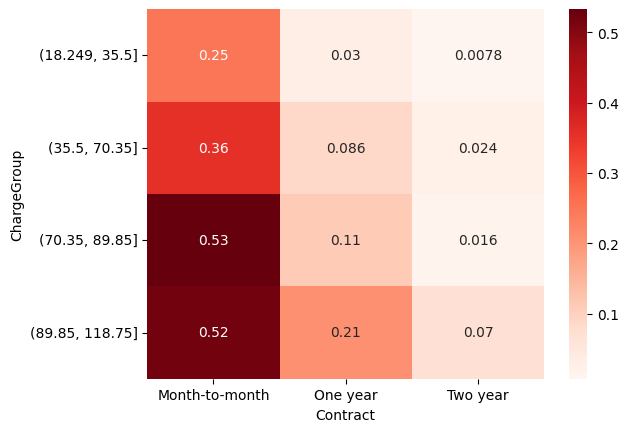

In [16]:
pivot = pd.crosstab(
    [df["ChargeGroup"], df["Contract"]],
    df["Churn"],
    normalize="index"
).reset_index()

pivot = pivot.pivot(index="ChargeGroup", columns="Contract", values="Yes")

sns.heatmap(pivot, annot=True, cmap="Reds")

ผมคิดว่า ยิ่งลูกค้า contract สั้น ไม่้ผูกสัญญา บริษัท ควรไม่ทําราคาสูงเกินไป หรือ มีตัวเลือกราคาหลายรูปแบบ เพื่อไม่กดดัน จํากัดตัวเลือกลูกค้า เพื่อรองลับลูกค้าได้ หลาย segment แต่ถ้าทําได้ ควร ดึงไห้ลูกค้าเหล่านั้น Contract มากที่สุด เช่น รายปี เป็นข้อผูกมัด